#IT25103066
Gradient Boosting (XGBoost)

Install XGBoost

In [1]:

!pip install xgboost -q

Import Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib

from xgboost import XGBRegressor

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

LOAD AND INSPECT DATA

Load the preprocessed dataset

In [3]:
train_df = pd.read_csv("processed_movie_reviews.csv")

print("Dataset loaded successfully!")
print("Dataset shape:", train_df.shape)

train_df.head()

Dataset loaded successfully!
Dataset shape: (9233, 26)


,movie_name,Ratings,word_count,emotion,cleaned_review,tokens_filtered,genre_action,genre_adventure,genre_animation,genre_comedy,...,genre_history,genre_horror,genre_music,genre_mystery,genre_romance,genre_science_fiction,genre_thriller,genre_tv_movie,genre_war,genre_western
0,Waiting to Exhale,3.0,56,anticipation,it had some laughs but overall the motivation ...,laughs overall motivation incomprehensible mad...,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
1,Waiting to Exhale,4.0,373,anticipation,waiting to exhale waiting and waiting and wait...,waiting exhale waiting waiting waiting waiting...,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
2,Waiting to Exhale,4.0,45,anticipation,angela basset was good as expected but whitney...,angela basset good expected whitney range actr...,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
3,Waiting to Exhale,5.0,124,anticipation,the movie is okay mediocre might even be the w...,okay mediocre word say tell act angela bassett...,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
4,Waiting to Exhale,5.0,212,anticipation,i got an opportunity to see waiting to exhale ...,got opportunity waiting exhale second recently...,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0


Inspect columns

In [4]:
print("Dataset columns:")
print(train_df.columns.tolist())

Dataset columns:
['movie_name', 'Ratings', 'word_count', 'emotion', 'cleaned_review', 'tokens_filtered', 'genre_action', 'genre_adventure', 'genre_animation', 'genre_comedy', 'genre_crime', 'genre_documentary', 'genre_drama', 'genre_family', 'genre_fantasy', 'genre_foreign', 'genre_history', 'genre_horror', 'genre_music', 'genre_mystery', 'genre_romance', 'genre_science_fiction', 'genre_thriller', 'genre_tv_movie', 'genre_war', 'genre_western']


Check data types

In [5]:
print("Data types:")
print(train_df.dtypes)

Data types:
movie_name                object
Ratings                  float64
word_count                 int64
emotion                   object
cleaned_review            object
tokens_filtered           object
genre_action             float64
genre_adventure          float64
genre_animation          float64
genre_comedy             float64
genre_crime              float64
genre_documentary        float64
genre_drama              float64
genre_family             float64
genre_fantasy            float64
genre_foreign            float64
genre_history            float64
genre_horror             float64
genre_music              float64
genre_mystery            float64
genre_romance            float64
genre_science_fiction    float64
genre_thriller           float64
genre_tv_movie           float64
genre_war                float64
genre_western            float64
dtype: object


Check missing values

In [6]:
print("Missing values:")
print(train_df.isnull().sum())

Missing values:
movie_name               0
Ratings                  0
word_count               0
emotion                  0
cleaned_review           0
tokens_filtered          0
genre_action             1
genre_adventure          1
genre_animation          1
genre_comedy             1
genre_crime              1
genre_documentary        1
genre_drama              1
genre_family             1
genre_fantasy            1
genre_foreign            1
genre_history            1
genre_horror             1
genre_music              1
genre_mystery            1
genre_romance            1
genre_science_fiction    1
genre_thriller           1
genre_tv_movie           1
genre_war                1
genre_western            1
dtype: int64


Check the target variable

In [7]:
print("Target variable: Ratings")

print("\nMinimum rating:", train_df["Ratings"].min())
print("Maximum rating:", train_df["Ratings"].max())

print("\nRating distribution:")
print(train_df["Ratings"].value_counts().sort_index())

Target variable: Ratings

Minimum rating: 1.0
Maximum rating: 10.0

Rating distribution:
Ratings
1.0      446
2.0      774
3.0      834
4.0      772
5.0      794
6.0      898
7.0     1115
8.0     1151
9.0     1075
10.0    1374
Name: count, dtype: int64


SELECT FEATURES

Define target and full feature set

In [8]:
target_column = "Ratings"

feature_columns = [
    "word_count",
    "genre_action",
    "genre_adventure",
    "genre_animation",
    "genre_comedy",
    "genre_crime",
    "genre_documentary",
    "genre_drama",
    "genre_family",
    "genre_fantasy",
    "genre_foreign",
    "genre_history",
    "genre_horror",
    "genre_music",
    "genre_mystery",
    "genre_romance",
    "genre_science_fiction",
    "genre_thriller",
    "genre_tv_movie",
    "genre_war",
    "genre_western"
]

X = train_df[feature_columns]
y = train_df[target_column]

print("Features:", X.shape)
print("Target:", y.shape)

Features: (9233, 21)
Target: (9233,)


Display selected features

In [9]:
print("Features used by XGBoost:")
for feature in feature_columns:
    print("-", feature)

Features used by XGBoost:
- word_count
- genre_action
- genre_adventure
- genre_animation
- genre_comedy
- genre_crime
- genre_documentary
- genre_drama
- genre_family
- genre_fantasy
- genre_foreign
- genre_history
- genre_horror
- genre_music
- genre_mystery
- genre_romance
- genre_science_fiction
- genre_thriller
- genre_tv_movie
- genre_war
- genre_western


TRAIN/VALIDATION SPLIT


Split the data

In [10]:
X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training samples:", len(X_train))
print("Validation samples:", len(X_val))

Training samples: 7386
Validation samples: 1847


MODEL VARIANT 1: BASELINE XGBOOST

Create baseline model

In [11]:
baseline_model = XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    subsample=1.0,
    colsample_bytree=1.0,
    random_state=42,
    objective="reg:squarederror"
)

print("Baseline XGBoost model created.")

Baseline XGBoost model created.


Train baseline model

In [12]:
baseline_model.fit(X_train, y_train)

print("Baseline XGBoost model trained.")

Baseline XGBoost model trained.


Predict using baseline model

In [13]:
baseline_pred = baseline_model.predict(X_val)

print("First 10 predictions:")
print(baseline_pred[:10])

First 10 predictions:
[6.863642  6.24007   5.7571845 6.608164  7.3819532 4.7323365 6.134263
 6.134672  6.1254935 5.9468083]


Evaluate baseline model

In [14]:
baseline_mae = mean_absolute_error(y_val, baseline_pred)

baseline_mse = mean_squared_error(y_val, baseline_pred)

baseline_rmse = np.sqrt(baseline_mse)

baseline_r2 = r2_score(y_val, baseline_pred)

print("BASELINE XGBOOST")
print("================")
print(f"MAE  : {baseline_mae:.4f}")
print(f"MSE  : {baseline_mse:.4f}")
print(f"RMSE : {baseline_rmse:.4f}")
print(f"R²   : {baseline_r2:.4f}")

BASELINE XGBOOST
MAE  : 2.3477
MSE  : 7.4946
RMSE : 2.7376
R²   : 0.0173


MODEL VARIANT 2: DIFFERENT PREPROCESSING / FEATURE SET

Create genre-only feature set

In [15]:
genre_features = [
    "genre_action",
    "genre_adventure",
    "genre_animation",
    "genre_comedy",
    "genre_crime",
    "genre_documentary",
    "genre_drama",
    "genre_family",
    "genre_fantasy",
    "genre_foreign",
    "genre_history",
    "genre_horror",
    "genre_music",
    "genre_mystery",
    "genre_romance",
    "genre_science_fiction",
    "genre_thriller",
    "genre_tv_movie",
    "genre_war",
    "genre_western"
]

X_genre = train_df[genre_features]

X_train_genre, X_val_genre, y_train_genre, y_val_genre = train_test_split(
    X_genre,
    y,
    test_size=0.20,
    random_state=42
)

print("Genre-only feature shape:", X_genre.shape)

Genre-only feature shape: (9233, 20)


Train genre-only XGBoost

In [16]:
genre_model = XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    subsample=1.0,
    colsample_bytree=1.0,
    random_state=42,
    objective="reg:squarederror"
)

genre_model.fit(X_train_genre, y_train_genre)

print("Genre-only XGBoost model trained.")

Genre-only XGBoost model trained.


Evaluate genre-only model

In [17]:
genre_pred = genre_model.predict(X_val_genre)

genre_mae = mean_absolute_error(y_val_genre, genre_pred)

genre_mse = mean_squared_error(y_val_genre, genre_pred)

genre_rmse = np.sqrt(genre_mse)

genre_r2 = r2_score(y_val_genre, genre_pred)

print("GENRE-ONLY XGBOOST")
print("==================")
print(f"MAE  : {genre_mae:.4f}")
print(f"MSE  : {genre_mse:.4f}")
print(f"RMSE : {genre_rmse:.4f}")
print(f"R²   : {genre_r2:.4f}")

GENRE-ONLY XGBOOST
MAE  : 2.3433
MSE  : 7.4535
RMSE : 2.7301
R²   : 0.0227


MODEL VARIANT 3: MANUAL HYPERPARAMETER CHANGE

Create manually tuned model

In [18]:
manual_model = XGBRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    objective="reg:squarederror"
)

print("Manually tuned XGBoost model created.")

Manually tuned XGBoost model created.


Train manually tuned model

In [19]:
manual_model.fit(X_train, y_train)

print("Manually tuned XGBoost model trained.")

Manually tuned XGBoost model trained.


Evaluate manually tuned model

In [20]:
manual_pred = manual_model.predict(X_val)

manual_mae = mean_absolute_error(y_val, manual_pred)

manual_mse = mean_squared_error(y_val, manual_pred)

manual_rmse = np.sqrt(manual_mse)

manual_r2 = r2_score(y_val, manual_pred)

print("MANUALLY TUNED XGBOOST")
print("======================")
print(f"MAE  : {manual_mae:.4f}")
print(f"MSE  : {manual_mse:.4f}")
print(f"RMSE : {manual_rmse:.4f}")
print(f"R²   : {manual_r2:.4f}")

MANUALLY TUNED XGBOOST
MAE  : 2.3415
MSE  : 7.4758
RMSE : 2.7342
R²   : 0.0198


HYPERPARAMETER TUNING USING GRIDSEARCHCV

Create tuning model

In [21]:
tuning_model = XGBRegressor(
    objective="reg:squarederror",
    random_state=42
)

print("XGBoost tuning model created.")

XGBoost tuning model created.


Define hyperparameter grid

In [22]:
param_grid = {
    "n_estimators": [100, 200],
    "learning_rate": [0.05, 0.1],
    "max_depth": [3, 5]
}

print("Hyperparameter grid:")
print(param_grid)

Hyperparameter grid:
{'n_estimators': [100, 200], 'learning_rate': [0.05, 0.1], 'max_depth': [3, 5]}


5-FOLD CROSS-VALIDATION + GRID SEARCH

Run GridSearchCV

In [23]:
grid_search = GridSearchCV(
    estimator=tuning_model,
    param_grid=param_grid,
    scoring="neg_mean_squared_error",
    cv=5,
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

print("Grid search completed successfully!")

Fitting 5 folds for each of 8 candidates, totalling 40 fits
Grid search completed successfully!


Display number of models/combinations tested

In [24]:
print("Number of hyperparameter combinations tested:",
      len(grid_search.cv_results_["params"]))

print("\nTotal parameter combinations:")
for params in grid_search.cv_results_["params"]:
    print(params)

Number of hyperparameter combinations tested: 8

Total parameter combinations:
{'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 100}
{'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 200}
{'learning_rate': 0.05, 'max_depth': 5, 'n_estimators': 100}
{'learning_rate': 0.05, 'max_depth': 5, 'n_estimators': 200}
{'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100}
{'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 200}
{'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 100}
{'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 200}


Display best hyperparameters

In [25]:
print("BEST HYPERPARAMETERS")
print("====================")

print(grid_search.best_params_)

BEST HYPERPARAMETERS
{'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100}


Get the best tuned model

In [26]:
tuned_model = grid_search.best_estimator_

print("Best tuned XGBoost model selected.")

Best tuned XGBoost model selected.


EVALUATE THE FINAL TUNED MODEL

Predict using tuned model

In [27]:
tuned_pred = tuned_model.predict(X_val)

print("Tuned model predictions generated.")

Tuned model predictions generated.


Evaluate tuned model

In [28]:
tuned_mae = mean_absolute_error(y_val, tuned_pred)

tuned_mse = mean_squared_error(y_val, tuned_pred)

tuned_rmse = np.sqrt(tuned_mse)

tuned_r2 = r2_score(y_val, tuned_pred)

print("TUNED XGBOOST")
print("=============")
print(f"MAE  : {tuned_mae:.4f}")
print(f"MSE  : {tuned_mse:.4f}")
print(f"RMSE : {tuned_rmse:.4f}")
print(f"R²   : {tuned_r2:.4f}")

TUNED XGBOOST
MAE  : 2.3477
MSE  : 7.4946
RMSE : 2.7376
R²   : 0.0173


EXPLICIT 5-FOLD CROSS-VALIDATION OF FINAL MODEL

5-fold cross-validation

In [29]:
cv_scores = cross_val_score(
    tuned_model,
    X,
    y,
    cv=5,
    scoring="neg_mean_squared_error",
    n_jobs=-1
)

cv_mse_scores = -cv_scores
cv_rmse_scores = np.sqrt(cv_mse_scores)

print("5-FOLD CROSS-VALIDATION RESULTS")
print("================================")

for i, score in enumerate(cv_rmse_scores, start=1):
    print(f"Fold {i} RMSE: {score:.4f}")

print(f"\nMean CV RMSE: {cv_rmse_scores.mean():.4f}")
print(f"Std CV RMSE : {cv_rmse_scores.std():.4f}")

5-FOLD CROSS-VALIDATION RESULTS
Fold 1 RMSE: 2.7660
Fold 2 RMSE: 2.8504
Fold 3 RMSE: 2.7805
Fold 4 RMSE: 2.8754
Fold 5 RMSE: 2.7155

Mean CV RMSE: 2.7975
Std CV RMSE : 0.0581


COMPARE ALL XGBOOST VARIANTS

Create comparison table

In [30]:
results = pd.DataFrame({
    "Model": [
        "Baseline XGBoost",
        "Genre-only XGBoost",
        "Manual Tuned XGBoost",
        "GridSearch Tuned XGBoost"
    ],
    "MAE": [
        baseline_mae,
        genre_mae,
        manual_mae,
        tuned_mae
    ],
    "MSE": [
        baseline_mse,
        genre_mse,
        manual_mse,
        tuned_mse
    ],
    "RMSE": [
        baseline_rmse,
        genre_rmse,
        manual_rmse,
        tuned_rmse
    ],
    "R2": [
        baseline_r2,
        genre_r2,
        manual_r2,
        tuned_r2
    ]
})

results

,Model,MAE,MSE,RMSE,R2
0,Baseline XGBoost,2.347667,7.494637,2.737633,0.017333
1,Genre-only XGBoost,2.343290,7.453548,2.730119,0.022720
2,Manual Tuned XGBoost,2.341471,7.475784,2.734188,0.019805
3,GridSearch Tuned XGBoost,2.347667,7.494637,2.737633,0.017333


Identify the best XGBoost variant

Find best model based on RMSE

In [31]:
best_model_row = results.loc[results["RMSE"].idxmin()]

print("BEST XGBOOST VARIANT")
print("====================")

print("Model:", best_model_row["Model"])
print("RMSE:", round(best_model_row["RMSE"], 4))
print("MAE:", round(best_model_row["MAE"], 4))
print("R²:", round(best_model_row["R2"], 4))

BEST XGBOOST VARIANT
Model: Genre-only XGBoost
RMSE: 2.7301
MAE: 2.3433
R²: 0.0227


FEATURE IMPORTANCE

Calculate feature importance

In [32]:
feature_importance = pd.DataFrame({
    "Feature": feature_columns,
    "Importance": tuned_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance

,Feature,Importance
13,genre_music,0.085416
5,genre_crime,0.080383
10,genre_foreign,0.074992
15,genre_romance,0.069314
17,genre_thriller,0.067773
14,genre_mystery,0.063918
4,genre_comedy,0.061187
3,genre_animation,0.059699
19,genre_war,0.049833
9,genre_fantasy,0.047595


Plot top 15 features

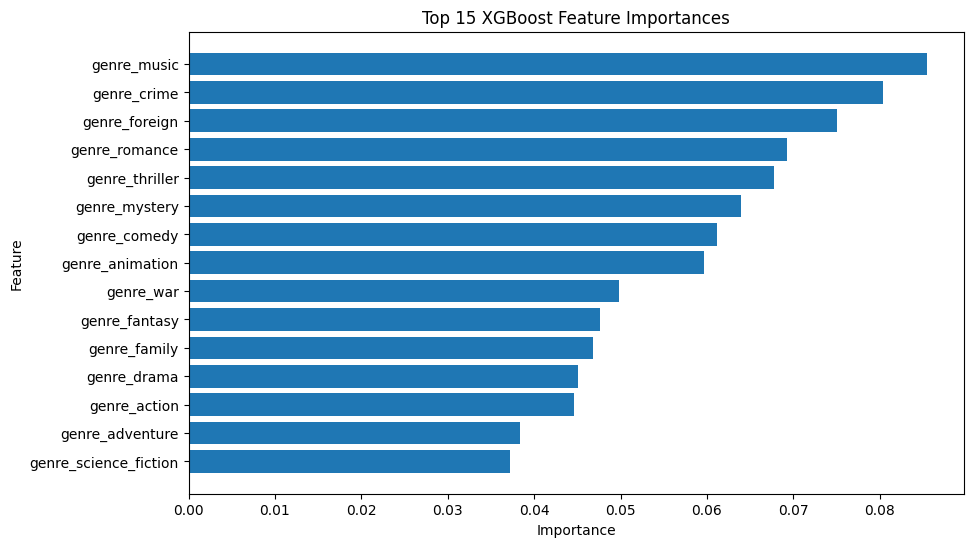

In [33]:
top_features = feature_importance.head(15)

plt.figure(figsize=(10, 6))

plt.barh(
    top_features["Feature"][::-1],
    top_features["Importance"][::-1]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 15 XGBoost Feature Importances")

plt.show()

ACTUAL VS PREDICTED RATINGS

Plot predictions

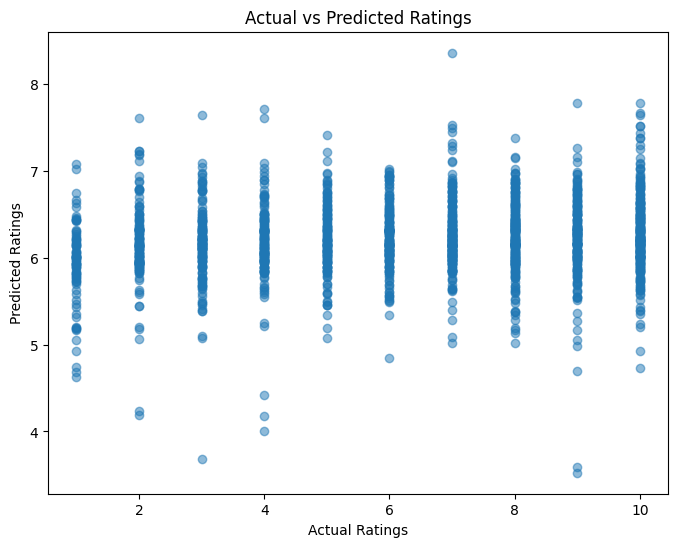

In [34]:
plt.figure(figsize=(8, 6))

plt.scatter(
    y_val,
    tuned_pred,
    alpha=0.5
)

plt.xlabel("Actual Ratings")
plt.ylabel("Predicted Ratings")
plt.title("Actual vs Predicted Ratings")

plt.show()

SAVE THE FINAL MODEL

Save model

In [35]:
model_data = {
    "model": tuned_model,
    "feature_columns": feature_columns,
    "target_column": target_column
}

joblib.dump(
    model_data,
    "xgboost_movie_rating_model.pkl"
)

print("Final XGBoost model saved successfully!")

Final XGBoost model saved successfully!
